In [ ]:
!pip install timm facenet-pytorch scikit-learn tqdm -q

from google.colab import drive
drive.mount('/content/drive')

     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 61.0/61.0 kB 2.6 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.9/1.9 MB 41.9 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 18.0/18.0 MB 63.8 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 4.5/4.5 MB 51.3 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 755.5/755.5 MB 2.1 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 410.6/410.6 MB 4.5 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 14.1/14.1 MB 33.0 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 23.7/23.7 MB 83.0 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 823.6/823.6 kB 63.9 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 731.7/731.7 MB 1.4 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 121.6/121.6 MB 7.8 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 56.5/56.5 MB 15.2 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 124.2

In [ ]:
!pip install --upgrade Pillow


   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 7.0/7.0 MB 119.3 MB/s eta 0:00:00
  Attempting uninstall: Pillow
    Found existing installation: pillow 10.2.0
    Uninstalling pillow-10.2.0:
      Successfully uninstalled pillow-10.2.0
ERROR: pip's dependency resolver does not currently take into account all the packages that are installed. This behaviour is the source of the following dependency conflicts.
facenet-pytorch 2.6.0 requires Pillow<10.3.0,>=10.2.0, but you have pillow 12.1.1 which is incompatible.
gradio 5.50.0 requires pillow<12.0,>=8.0, but you have pillow 12.1.1 which is incompatible.


In [ ]:
pip install "numpy<2.0" "torch==2.2.2" "torchvision==0.17.2" "torchaudio==2.2.2" --force-reinstall


  Using cached numpy-1.26.4-cp312-cp312-manylinux_2_17_x86_64.manylinux2014_x86_64.whl.metadata (61 kB)
  Using cached torch-2.2.2-cp312-cp312-manylinux1_x86_64.whl.metadata (25 kB)
  Using cached torchvision-0.17.2-cp312-cp312-manylinux1_x86_64.whl.metadata (6.6 kB)
  Using cached nvidia_cuda_nvrtc_cu12-12.1.105-py3-none-manylinux1_x86_64.whl.metadata (1.5 kB)
  Using cached nvidia_cuda_runtime_cu12-12.1.105-py3-none-manylinux1_x86_64.whl.metadata (1.5 kB)
  Using cached nvidia_cuda_cupti_cu12-12.1.105-py3-none-manylinux1_x86_64.whl.metadata (1.6 kB)
  Using cached nvidia_cudnn_cu12-8.9.2.26-py3-none-manylinux1_x86_64.whl.metadata (1.6 kB)
  Using cached nvidia_cublas_cu12-12.1.3.1-py3-none-manylinux1_x86_64.whl.metadata (1.5 kB)
  Using cached nvidia_cufft_cu12-11.0.2.54-py3-none-manylinux1_x86_64.whl.metadata (1.5 kB)
  Using cached nvidia_curand_cu12-10.3.2.106-py3-none-manylinux1_x86_64.whl.metadata (1.5 kB)
  Using cached nvidia_cusolver_cu12-11.4.5.107-py3-none-manylinux1_x86_64

In [ ]:
!pip install "numpy<2"


In [ ]:
import shutil, os

DRIVE_DATA = "/content/drive/MyDrive/processed_v3"   # your saved data
LOCAL_DATA = DRIVE_DATA               # local fast SSD
MODEL_LOCAL = "/content/deepfake_v4_best.pth"
MODEL_DRIVE = "/content/drive/MyDrive/deepfake_v4_best.pth"

if not os.path.exists(LOCAL_DATA):
    print("Copying from Drive to local SSD...")
    shutil.copytree(DRIVE_DATA, LOCAL_DATA, dirs_exist_ok=True)
else:
    print("Local data already exists, skipping copy.")

pts = [f for f in os.listdir(LOCAL_DATA) if f.endswith('.pt')]
print(f"Total .pt files: {len(pts)}")

Local data already exists, skipping copy.
Total .pt files: 2050


In [ ]:
import os, random, time
import numpy as np
import torch
import torch.nn as nn
import torch.nn.functional as F
import torchvision.transforms as T
import timm
import matplotlib.pyplot as plt

from torch.utils.data import Dataset, DataLoader, random_split, WeightedRandomSampler
from torch.optim import AdamW
from tqdm import tqdm
from sklearn.metrics import roc_auc_score, accuracy_score, f1_score, classification_report, confusion_matrix
import seaborn as sns

def set_seed(seed=42):
    random.seed(seed)
    np.random.seed(seed)
    torch.manual_seed(seed)
    torch.cuda.manual_seed_all(seed)
    torch.backends.cudnn.deterministic = True

set_seed(42)
device = 'cuda' if torch.cuda.is_available() else 'cpu'
print(f"Device: {device}")
print(f"PyTorch: {torch.__version__}")

Device: cuda
PyTorch: 2.2.2+cu121


In [ ]:

def augment_video(video, is_train=True):
    """
    video: T, C, H, W tensor (normalized)
    Returns augmented tensor of same shape.
    """
    if not is_train:
        return video

    T_len = video.shape[0]

    if random.random() > 0.5:
        video = torch.flip(video, dims=[3])


    if random.random() > 0.7:
        idx = sorted(random.choices(range(T_len), k=T_len))
        video = video[idx]

    if random.random() > 0.5:
        brightness = random.uniform(0.85, 1.15)
        video = video * brightness

    if random.random() > 0.5:
        contrast = random.uniform(0.85, 1.15)
        mean = video.mean(dim=[2,3], keepdim=True)
        video = (video - mean) * contrast + mean


    if random.random() > 0.7:
        noise = torch.randn_like(video) * 0.02
        video = video + noise

    return video.clamp(-3.0, 3.0)


class TensorVideoDataset(Dataset):
    def __init__(self, folder, is_train=True):
        self.folder   = folder
        self.is_train = is_train
        self.files    = sorted(
            [f for f in os.listdir(folder) if f.endswith(".pt")],
            key=lambda x: int(x.replace(".pt", ""))
        )

    def __len__(self):
        return len(self.files)

    def __getitem__(self, idx):
        try:
            data  = torch.load(
                os.path.join(self.folder, self.files[idx]),
                map_location="cpu", weights_only=False
            )
            video = data["video"].float()              # T, C, H, W
            label = torch.tensor(data["label"], dtype=torch.long)
            video = augment_video(video, self.is_train)
            return video, label
        except Exception:
            return torch.zeros(16, 3, 224, 224), torch.tensor(0)

    def get_labels(self):
        labels = []
        for f in self.files:
            try:
                d = torch.load(os.path.join(self.folder, f),
                               map_location="cpu", weights_only=False)
                labels.append(int(d["label"]))
            except Exception:
                labels.append(0)
        return labels


print("Dataset class ready.")

Dataset class ready.


In [ ]:
full_dataset = TensorVideoDataset(LOCAL_DATA, is_train=True)
all_labels   = full_dataset.get_labels()


train_size = int(0.85 * len(full_dataset))
val_size   = len(full_dataset) - train_size

train_dataset, val_dataset = random_split(
    full_dataset, [train_size, val_size],
    generator=torch.Generator().manual_seed(42)
)


val_dataset.dataset.is_train = False


train_labels   = [all_labels[i] for i in train_dataset.indices]
class_counts   = np.bincount(train_labels)
class_weights  = 1.0 / class_counts
sample_weights = [class_weights[l] for l in train_labels]
sampler        = WeightedRandomSampler(sample_weights, len(train_labels), replacement=True)

train_loader = DataLoader(train_dataset, batch_size=4, sampler=sampler,
                           num_workers=2, pin_memory=True, persistent_workers=True)
val_loader   = DataLoader(val_dataset,   batch_size=4, shuffle=False,
                           num_workers=2, pin_memory=True, persistent_workers=True)

print(f"Train: {len(train_dataset)} | Val: {len(val_dataset)}")
print(f"Real (0): {class_counts[0]} | Fake (1): {class_counts[1]}")


vids, lbls = next(iter(train_loader))
print(f"Batch shape: {vids.shape} | Labels: {lbls.tolist()}")

Train: 1742 | Val: 308
Real (0): 683 | Fake (1): 1059
Batch shape: torch.Size([4, 16, 3, 224, 224]) | Labels: [1, 0, 0, 1]


In [ ]:
class SpatialCNN(nn.Module):
    """
    EfficientNet-B4 fully unfrozen.
    CRITICAL FIX: previous version froze too many layers causing 50% accuracy.
    All layers trainable with differential LR via optimizer param groups.
    """
    def __init__(self):
        super().__init__()
        self.backbone    = timm.create_model('efficientnet_b4', pretrained=True)
        self.feature_dim = self.backbone.classifier.in_features  # 1792
        self.backbone.classifier  = nn.Identity()
        self.backbone.global_pool = nn.Identity()
        self.pool = nn.AdaptiveAvgPool2d(1)
        # ALL layers trainable — differential LR handles this in optimizer
        for param in self.backbone.parameters():
            param.requires_grad = True

    def forward(self, x):   # x: B, C, H, W
        feat = self.backbone.forward_features(x)      # B, 1792, H', W'
        return self.pool(feat).squeeze(-1).squeeze(-1) # B, 1792


class FrequencyBranch(nn.Module):
    """FFT-based GAN artifact detector."""
    def __init__(self, out_dim=64):
        super().__init__()
        self.conv = nn.Sequential(
            nn.Conv2d(3, 16, 3, padding=1), nn.BatchNorm2d(16), nn.ReLU(), nn.MaxPool2d(4),
            nn.Conv2d(16, 32, 3, padding=1), nn.BatchNorm2d(32), nn.ReLU(),
            nn.AdaptiveAvgPool2d(4)
        )
        self.fc = nn.Linear(32*4*4, out_dim)

    def forward(self, x):   # x: B*T, C, H, W
        with torch.cuda.amp.autocast(enabled=False):
            f   = torch.fft.fftshift(torch.fft.fft2(x.float(), norm='ortho'))
            mag = torch.log1p(f.abs())
        mag = mag / (mag.flatten(2).max(dim=2).values.unsqueeze(-1).unsqueeze(-1) + 1e-6)
        return self.fc(self.conv(mag.to(x.dtype)).flatten(1))


class rPPGBranch(nn.Module):
    """Green-channel heartbeat signal analyzer."""
    def __init__(self, out_dim=64):
        super().__init__()
        self.conv = nn.Sequential(
            nn.Conv1d(1, 32, 5, padding=2), nn.BatchNorm1d(32), nn.ReLU(),
            nn.Conv1d(32, 64, 5, padding=2), nn.BatchNorm1d(64), nn.ReLU()
        )
        self.attn = nn.MultiheadAttention(64, num_heads=4, batch_first=True)
        self.pool = nn.AdaptiveAvgPool1d(1)

    def forward(self, signal):   # B, T
        x = self.conv(signal.unsqueeze(1))    # B, 64, T
        x = x.permute(0, 2, 1)               # B, T, 64
        x, _ = self.attn(x, x, x)
        return self.pool(x.permute(0,2,1)).squeeze(-1)  # B, 64


class TemporalBiLSTM(nn.Module):
    """
    BiLSTM with attention pooling.
    Bidirectional = captures both forward and backward temporal context.
    """
    def __init__(self, input_size=1792, hidden=512, num_layers=2, out_dim=512):
        super().__init__()
        self.bilstm   = nn.LSTM(input_size, hidden, num_layers,
                                 batch_first=True, bidirectional=True, dropout=0.3)
        self.attn     = nn.Linear(hidden*2, 1)
        self.out_proj = nn.Linear(hidden*2, out_dim)
        self.norm     = nn.LayerNorm(out_dim)

    def forward(self, x):   # B, T, F
        out, _  = self.bilstm(x)                         # B, T, hidden*2
        weights = torch.softmax(self.attn(out), dim=1)   # B, T, 1
        context = (out * weights).sum(dim=1)              # B, hidden*2
        return self.norm(self.out_proj(context))          # B, out_dim


class DeepfakeDetector(nn.Module):
    def __init__(self):
        super().__init__()
        self.spatial  = SpatialCNN()
        feat_dim      = self.spatial.feature_dim   # 1792

        self.temporal = TemporalBiLSTM(feat_dim, hidden=512, num_layers=2, out_dim=512)
        self.rppg     = rPPGBranch(out_dim=64)
        self.freq     = FrequencyBranch(out_dim=64)

        fusion_dim = 512 + 64 + 64   # 640

        # Stronger classifier with residual
        self.fc1   = nn.Linear(fusion_dim, 256)
        self.fc2   = nn.Linear(256, 256)
        self.fc_out = nn.Linear(256, 2)
        self.drop1 = nn.Dropout(0.4)
        self.drop2 = nn.Dropout(0.3)
        self.norm1 = nn.LayerNorm(fusion_dim)
        self.norm2 = nn.LayerNorm(256)

    def extract_rppg(self, frames):   # B, T, C, H, W
        sig  = frames[:,:,1,:,:].mean(dim=(2,3))   # B, T
        return (sig - sig.mean(1,keepdim=True)) / (sig.std(1,keepdim=True) + 1e-6)

    def forward(self, frames):   # B, T, C, H, W
        B, T, C, H, W = frames.shape
        flat          = frames.view(B*T, C, H, W)

        # Spatial + Temporal
        sp   = self.spatial(flat).view(B, T, -1)   # B, T, 1792
        temp = self.temporal(sp)                    # B, 512

        # rPPG
        rppg = self.rppg(self.extract_rppg(frames)) # B, 64

        # Frequency
        freq = self.freq(flat).view(B, T, -1).mean(1)  # B, 64

        # Fusion with residual classifier
        fused = self.norm1(torch.cat([temp, rppg, freq], dim=1))  # B, 640
        x     = F.gelu(self.fc1(fused))                           # B, 256
        x     = self.drop1(x)
        x     = self.norm2(x + F.gelu(self.fc2(x)))               # residual
        x     = self.drop2(x)
        return self.fc_out(x)


# Build and verify
model = DeepfakeDetector().to(device)
with torch.no_grad():
    dummy = torch.randn(2, 16, 3, 224, 224).to(device)
    out   = model(dummy)
print(f"Output shape:     {out.shape}")
print(f"Total params:     {sum(p.numel() for p in model.parameters()):,}")
print(f"Trainable params: {sum(p.numel() for p in model.parameters() if p.requires_grad):,}")

/usr/local/lib/python3.12/dist-packages/huggingface_hub/utils/_auth.py:94: UserWarning: 
The secret `HF_TOKEN` does not exist in your Colab secrets.
To authenticate with the Hugging Face Hub, create a token in your settings tab (https://huggingface.co/settings/tokens), set it as secret in your Google Colab and restart your session.
You will be able to reuse this secret in all of your notebooks.
Please note that authentication is recommended but still optional to access public models or datasets.
  warnings.warn(


model.safetensors:   0%|          | 0.00/77.9M [00:00<?, ?B/s]

Output shape:     torch.Size([2, 2])
Total params:     34,118,027
Trainable params: 34,118,027


In [ ]:
EPOCHS = 20
# ── 3 param groups with different LRs ────────────────────────────────────────
# Group 1: Early EfficientNet layers (blocks 0-3) — very small LR
#           These have general features (edges, textures) — don't change much
# Group 2: Late EfficientNet layers (blocks 4-7) — small LR
#           These have semantic features — fine-tune carefully
# Group 3: BiLSTM + rPPG + Freq + Classifier — large LR
#           These are new, need to learn from scratch

early_bb = [p for n,p in model.named_parameters()
            if 'spatial.backbone' in n and
            any(f'blocks.{i}' in n for i in range(4))]

late_bb  = [p for n,p in model.named_parameters()
            if 'spatial.backbone' in n and
            any(f'blocks.{i}' in n for i in range(4,8))]

bb_other = [p for n,p in model.named_parameters()
            if 'spatial.backbone' in n and
            not any(f'blocks.{i}' in n for i in range(8))]

heads    = [p for n,p in model.named_parameters()
            if 'spatial' not in n]

optimizer = AdamW([
    {'params': early_bb,  'lr': 5e-6,  'weight_decay': 1e-4},   # very slow
    {'params': late_bb,   'lr': 2e-5,  'weight_decay': 1e-4},   # slow
    {'params': bb_other,  'lr': 1e-5,  'weight_decay': 1e-4},   # slow
    {'params': heads,     'lr': 2e-4,  'weight_decay': 1e-4},   # fast
])

# OneCycleLR: ramps up then decays — best for fine-tuning pretrained models
# This is much better than CosineAnnealing for our case
scheduler = torch.optim.lr_scheduler.OneCycleLR(
    optimizer,
    max_lr       = [5e-5, 2e-4, 1e-4, 1e-3],  # peak LR per group
    epochs       = EPOCHS,
    steps_per_epoch = len(train_loader),
    pct_start    = 0.2,    # 20% warmup
    anneal_strategy = 'cos',
    div_factor   = 10.0,   # start LR = max_lr / 10
    final_div_factor = 100.0
)

# CrossEntropy with label smoothing — simpler and more stable than Focal Loss
criterion = nn.CrossEntropyLoss(label_smoothing=0.1)

scaler = torch.cuda.amp.GradScaler(enabled=(device=='cuda'))

print(f"Early backbone params: {len(early_bb)}")
print(f"Late backbone params:  {len(late_bb)}")
print(f"Head params:           {len(heads)}")
print(f"Optimizer: AdamW + OneCycleLR over {EPOCHS} epochs")

Early backbone params: 202
Late backbone params:  208
Head params:           54
Optimizer: AdamW + OneCycleLR over 20 epochs


In [ ]:
best_auc  = 0.0
best_acc  = 0.0
history   = {'train_loss':[], 'train_acc':[], 'val_auc':[], 'val_acc':[], 'val_f1':[]}
GRAD_CLIP = 1.0


def train_one_epoch(model, loader, optimizer, criterion, scaler, scheduler, device, epoch):
    model.train()
    total_loss, correct, total = 0.0, 0, 0

    for videos, labels in tqdm(loader, desc=f"Epoch {epoch}", leave=False):
        videos = videos.to(device, non_blocking=True)
        labels = labels.to(device, non_blocking=True)

        # CutMix — better than MixUp for spatial tasks like deepfake detection
        # Only apply after epoch 3 when model has basic features
        if epoch > 3 and random.random() > 0.5:
            lam   = np.random.beta(1.0, 1.0)
            idx   = torch.randperm(videos.size(0), device=device)
            # Cut a random box and paste from another sample
            cut_w = int(224 * np.sqrt(1 - lam))
            cut_h = int(224 * np.sqrt(1 - lam))
            cx    = random.randint(0, 224 - cut_w)
            cy    = random.randint(0, 224 - cut_h)
            videos_cut = videos.clone()
            videos_cut[:,:,:,cy:cy+cut_h,cx:cx+cut_w] = videos[idx,:,:,cy:cy+cut_h,cx:cx+cut_w]
            lam_actual = 1 - (cut_w * cut_h) / (224 * 224)
            labels_b   = labels[idx]
            use_mixed  = True
        else:
            videos_cut = videos
            labels_b   = labels
            lam_actual = 1.0
            use_mixed  = False

        optimizer.zero_grad(set_to_none=True)

        with torch.cuda.amp.autocast(enabled=(device=='cuda')):
            out  = model(videos_cut)
            if use_mixed:
                loss = lam_actual*criterion(out,labels) + (1-lam_actual)*criterion(out,labels_b)
            else:
                loss = criterion(out, labels)

        scaler.scale(loss).backward()
        torch.nn.utils.clip_grad_norm_(model.parameters(), GRAD_CLIP)
        scaler.step(optimizer)
        scaler.update()
        scheduler.step()   # OneCycleLR steps every batch

        total_loss += loss.item()
        correct    += (out.argmax(1) == labels).sum().item()
        total      += labels.size(0)

    return total_loss / len(loader), correct / total


@torch.no_grad()
def validate(model, loader, device):
    model.eval()
    all_probs, all_preds, all_labels = [], [], []

    for videos, labels in tqdm(loader, desc="Val", leave=False):
        videos = videos.to(device, non_blocking=True)
        with torch.cuda.amp.autocast(enabled=(device=='cuda')):
            out = model(videos)
        probs = torch.softmax(out, dim=1)[:,1]
        all_probs.extend(probs.cpu().numpy())
        all_preds.extend(out.argmax(1).cpu().numpy())
        all_labels.extend(labels.numpy())

    return (
        roc_auc_score(all_labels, all_probs),
        accuracy_score(all_labels, all_preds),
        f1_score(all_labels, all_preds, average='weighted')
    )


# ── Main loop ─────────────────────────────────────────────────────────────────
print(f"Starting training for {EPOCHS} epochs...\n")

for epoch in range(1, EPOCHS+1):
    t0 = time.time()

    train_loss, train_acc    = train_one_epoch(
        model, train_loader, optimizer, criterion, scaler, scheduler, device, epoch
    )
    val_auc, val_acc, val_f1 = validate(model, val_loader, device)

    history['train_loss'].append(train_loss)
    history['train_acc'].append(train_acc)
    history['val_auc'].append(val_auc)
    history['val_acc'].append(val_acc)
    history['val_f1'].append(val_f1)

    current_lr = optimizer.param_groups[3]['lr']  # head LR
    elapsed    = (time.time()-t0)/60

    print(f"Epoch {epoch:02d}/{EPOCHS}  ({elapsed:.1f}m)  LR={current_lr:.2e}")
    print(f"  Train → Loss: {train_loss:.4f}  Acc: {train_acc:.4f}")
    print(f"  Val   → AUC:  {val_auc:.4f}   Acc: {val_acc:.4f}   F1: {val_f1:.4f}")

    # Save on best AUC
    if val_auc > best_auc:
        best_auc = val_auc
        best_acc = val_acc
        ckpt = {
            'epoch': epoch,
            'model_state_dict': model.state_dict(),
            'optimizer_state_dict': optimizer.state_dict(),
            'val_auc': val_auc,
            'val_acc': val_acc,
            'val_f1':  val_f1,
            'history': history,
            'model_config': {
                'backbone': 'efficientnet_b4',
                'frames_per_video': 16,
                'hidden': 512, 'num_layers': 2
            }
        }
        torch.save(ckpt, MODEL_LOCAL)
        torch.save(ckpt, MODEL_DRIVE)
        print(f"  ✅ Best saved → Drive  (AUC={best_auc:.4f}, Acc={best_acc:.4f})")

    print()

print(f"{'='*55}")
print(f"Training complete!")
print(f"Best Val AUC: {best_auc:.4f}")
print(f"Best Val Acc: {best_acc:.4f}")
print(f"Model saved:  {MODEL_DRIVE}")

Starting training for 20 epochs...



Epoch 1:   0%|          | 0/436 [00:00<?, ?it/s]/usr/local/lib/python3.12/dist-packages/torch/optim/lr_scheduler.py:143: UserWarning: Detected call of `lr_scheduler.step()` before `optimizer.step()`. In PyTorch 1.1.0 and later, you should call them in the opposite order: `optimizer.step()` before `lr_scheduler.step()`.  Failure to do this will result in PyTorch skipping the first value of the learning rate schedule. See more details at https://pytorch.org/docs/stable/optim.html#how-to-adjust-learning-rate
  warnings.warn("Detected call of `lr_scheduler.step()` before `optimizer.step()`. "


Epoch 01/20  (3.9m)  LR=2.32e-04
  Train → Loss: 0.7390  Acc: 0.5287
  Val   → AUC:  0.7054   Acc: 0.6656   F1: 0.6090
  ✅ Best saved → Drive  (AUC=0.7054, Acc=0.6656)



Epoch 02/20  (4.0m)  LR=5.50e-04
  Train → Loss: 0.6901  Acc: 0.6470
  Val   → AUC:  0.8295   Acc: 0.7468   F1: 0.7504
  ✅ Best saved → Drive  (AUC=0.8295, Acc=0.7468)



Epoch 03/20  (4.2m)  LR=8.69e-04
  Train → Loss: 0.6285  Acc: 0.7153
  Val   → AUC:  0.8602   Acc: 0.7792   F1: 0.7761
  ✅ Best saved → Drive  (AUC=0.8602, Acc=0.7792)



...

Epoch 06/20  (3.9m)  LR=9.62e-04
  Train → Loss: 0.6725  Acc: 0.6274
  Val   → AUC:  0.7707   Acc: 0.7338   F1: 0.7368



Epoch 07/20  (4.0m)  LR=9.16e-04
  Train → Loss: 0.6456  Acc: 0.6527
  Val   → AUC:  0.7938   Acc: 0.7338   F1: 0.7364



Epoch 08/20  (3.9m)  LR=8.54e-04
  Train → Loss: 0.6393  Acc: 0.6728
  Val   → AUC:  0.8344   Acc: 0.7695   F1: 0.7665



Epoch 09/20  (3.9m)  LR=7.78e-04
  Train → Loss: 0.6231  Acc: 0.6785
  Val   → AUC:  0.8188   Acc: 0.7695   F1: 0.7680



ValueError: Input contains NaN.

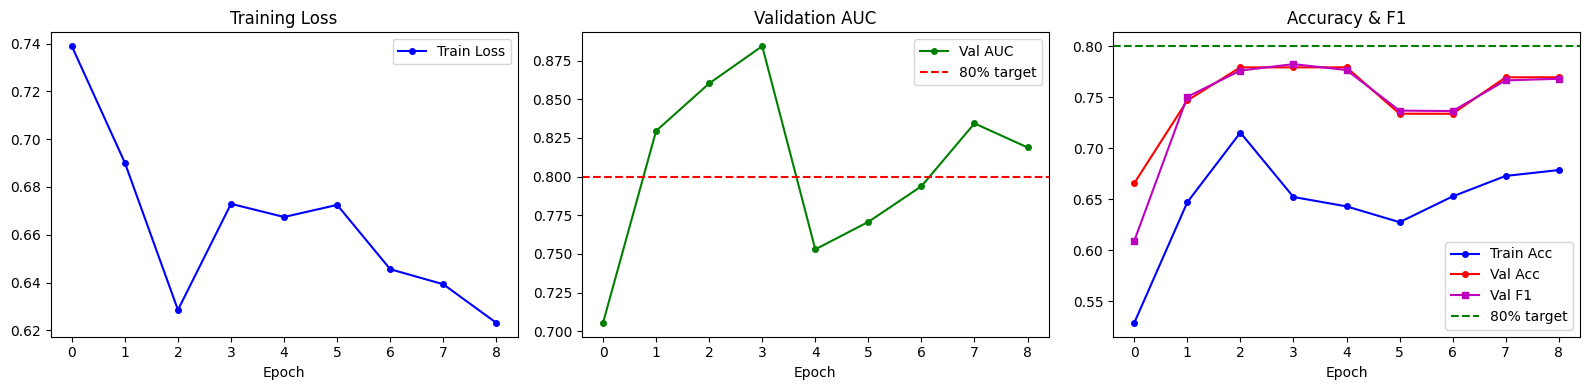

Best AUC: 0.8843
Best Acc: 0.7792


In [ ]:
fig, axes = plt.subplots(1, 3, figsize=(16, 4))

axes[0].plot(history['train_loss'], 'b-o', ms=4, label='Train Loss')
axes[0].set_title('Training Loss'); axes[0].set_xlabel('Epoch'); axes[0].legend()

axes[1].plot(history['val_auc'], 'g-o', ms=4, label='Val AUC')
axes[1].axhline(0.8, color='red', linestyle='--', label='80% target')
axes[1].set_title('Validation AUC'); axes[1].set_xlabel('Epoch'); axes[1].legend()

axes[2].plot(history['train_acc'], 'b-o', ms=4, label='Train Acc')
axes[2].plot(history['val_acc'],   'r-o', ms=4, label='Val Acc')
axes[2].plot(history['val_f1'],    'm-s', ms=4, label='Val F1')
axes[2].axhline(0.8, color='green', linestyle='--', label='80% target')
axes[2].set_title('Accuracy & F1'); axes[2].set_xlabel('Epoch'); axes[2].legend()

plt.tight_layout()
plt.savefig('/content/drive/MyDrive/training_curves_v4.png', dpi=150)
plt.show()

print(f"Best AUC: {max(history['val_auc']):.4f}")
print(f"Best Acc: {max(history['val_acc']):.4f}")

Loaded epoch 4  AUC=0.8843  Acc=0.7792


Evaluating: 100%|██████████| 77/77 [00:23<00:00,  3.24it/s]



=== Classification Report ===
              precision    recall  f1-score   support

        Real       0.65      0.89      0.75       117
        Fake       0.91      0.71      0.80       191

    accuracy                           0.78       308
   macro avg       0.78      0.80      0.78       308
weighted avg       0.81      0.78      0.78       308

Final AUC:      0.8844
Final Accuracy: 0.7792


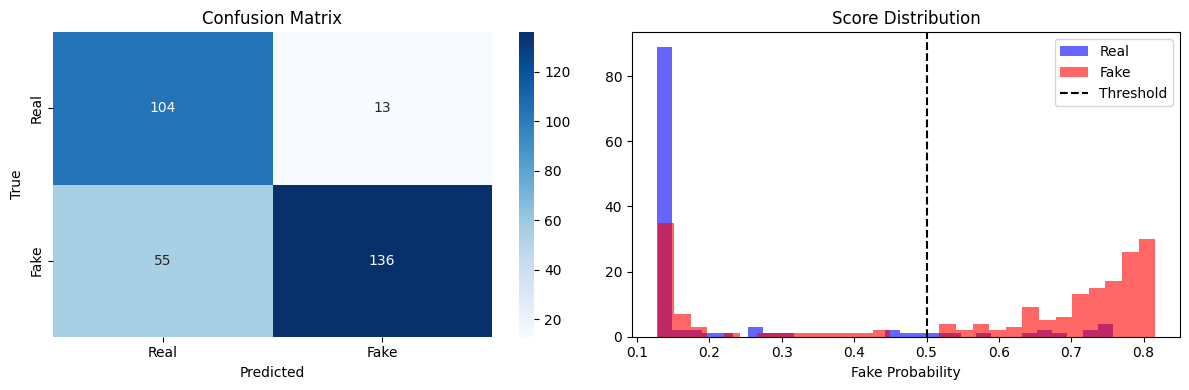

In [ ]:
# Load best checkpoint
ckpt = torch.load(MODEL_DRIVE, map_location=device)
model.load_state_dict(ckpt['model_state_dict'])
print(f"Loaded epoch {ckpt['epoch']}  AUC={ckpt['val_auc']:.4f}  Acc={ckpt['val_acc']:.4f}")

model.eval()
all_probs, all_preds, all_labels = [], [], []

with torch.no_grad():
    for videos, labels in tqdm(val_loader, desc="Evaluating"):
        out   = model(videos.to(device))
        probs = torch.softmax(out, dim=1)[:,1]
        all_probs.extend(probs.cpu().numpy())
        all_preds.extend(out.argmax(1).cpu().numpy())
        all_labels.extend(labels.numpy())

print("\n=== Classification Report ===")
print(classification_report(all_labels, all_preds, target_names=['Real','Fake']))
print(f"Final AUC:      {roc_auc_score(all_labels, all_probs):.4f}")
print(f"Final Accuracy: {accuracy_score(all_labels, all_preds):.4f}")

fig, axes = plt.subplots(1, 2, figsize=(12, 4))

# Confusion matrix
cm = confusion_matrix(all_labels, all_preds)
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', ax=axes[0],
            xticklabels=['Real','Fake'], yticklabels=['Real','Fake'])
axes[0].set_title('Confusion Matrix')
axes[0].set_ylabel('True'); axes[0].set_xlabel('Predicted')

# Score distribution
real_scores = [p for p,l in zip(all_probs, all_labels) if l==0]
fake_scores = [p for p,l in zip(all_probs, all_labels) if l==1]
axes[1].hist(real_scores, bins=30, alpha=0.6, color='blue', label='Real')
axes[1].hist(fake_scores, bins=30, alpha=0.6, color='red',  label='Fake')
axes[1].axvline(0.5, color='black', linestyle='--', label='Threshold')
axes[1].set_title('Score Distribution')
axes[1].set_xlabel('Fake Probability'); axes[1].legend()

plt.tight_layout()
plt.savefig('/content/drive/MyDrive/evaluation_v4.png', dpi=150)
plt.show()

In [ ]:
import cv2

val_transform = T.Compose([
    T.ToPILImage(),
    T.Resize((224, 224)),
    T.ToTensor(),
    T.Normalize([0.485,0.456,0.406],[0.229,0.224,0.225])
])

@torch.no_grad()
def predict_video(video_path, model, device, n_frames=16):
    cap    = cv2.VideoCapture(video_path)
    total  = max(int(cap.get(cv2.CAP_PROP_FRAME_COUNT)), 1)
    idxs   = [int(i*total/n_frames) for i in range(n_frames)]
    frames = []

    for i in idxs:
        cap.set(cv2.CAP_PROP_POS_FRAMES, i)
        ret, frame = cap.read()
        if not ret: continue
        frame = cv2.cvtColor(frame, cv2.COLOR_BGR2RGB)
        frames.append(val_transform(frame))
    cap.release()

    while len(frames) < n_frames: frames.append(frames[-1])
    tensor    = torch.stack(frames[:n_frames]).unsqueeze(0).to(device)
    model.eval()
    prob      = torch.softmax(model(tensor), dim=1)[0]
    fake_prob = prob[1].item()

    return {
        'label':     'FAKE' if fake_prob > 0.5 else 'REAL',
        'fake_prob': round(fake_prob, 4),
        'real_prob': round(prob[0].item(), 4)
    }

# result = predict_video('/path/to/video.mp4', model, device)
# print(result)
print("predict_video() ready.")

predict_video() ready.


In [ ]:
# ── Download best model from Drive to local and then to your PC ───────────────

# Step 1 — Copy from Drive to Colab local
!cp "/content/drive/MyDrive/deepfake_v4_best.pth" "/content/deepfake_v4_best.pth"
print("Copied to local!")

# Step 2 — Download to your PC
from google.colab import files
files.download("/content/deepfake_v4_best.pth")
print("Download started!")

Copied to local!


<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

Download started!
